# Retrieval

In [1]:
import numpy as np # Used for return type and embeddings .
import open_clip # Used to load image embedding model  .
import torch # Used for device handling and tensor operations .
import os # Used for locating database storage .
from sentence_transformers import SentenceTransformer # Used to load text embedding model .
import chromadb # Used for vectorDB operations .
from typing import Dict # Used for datatype handling .

In [2]:
# Used image embedding and query embedding .
class OpenClipTextEmbeddingModel:
     def __init__(self,model_name:str="ViT-B-32",pretrained:str="laion2b_s34b_b79k"):

        self.device="cuda" if torch.cuda.is_available() else "cpu" # Used to check if the machine has GPU if not assign CPU as device for working .
        self.model,self.preprocess,_=open_clip.create_model_and_transforms(
            model_name=model_name,
            pretrained=pretrained
        ) # Getting essential function from model .
        self.tokenizer=open_clip.get_tokenizer(model_name)
        self.model=self.model.to(self.device) # Device selection for model operations .
        self.model.eval() # Loading model

        # Displaying device on which model will run .
        if self.device=="cuda":
            print(f"OpenClip running on {torch.cuda.get_device_name(0)} .")
        else:
            print("OpenClip running on CPU .")
        print(f"Embedding dimensions of {model_name} is {open_clip.get_model_config(model_name).get('embed_dim')}")

     @torch.no_grad()
     def embed_query(self,query:str)->np.ndarray:
         if not query.strip():
             raise ValueError("Please give a valid prompt .")

         tokens=self.tokenizer([query]).to(self.device) # Used to convert into tensor .
         query_embedding=self.model.encode_text(tokens) # Embedding text or tensor value .
         query_embedding=query_embedding/query_embedding.norm(dim=-1,keepdim=True) # Normalizing values
         query_embedding=query_embedding.cpu().numpy()[0] # Converting tensor to numpy array .

         return query_embedding # Returning all the embeddings .

In [3]:
image_model=OpenClipTextEmbeddingModel()

OpenClip running on NVIDIA GeForce RTX 3050 6GB Laptop GPU .
Embedding dimensions of ViT-B-32 is 512


In [4]:
# Used for text embedding and query embedding .
class BGETextEmbeddingModel:

    def __init__(self,model_name:str= "BAAI/bge-base-en-v1.5"):
        self.device="cuda" if torch.cuda.is_available() else "cpu" # Device check .
        self.model=SentenceTransformer(model_name_or_path=model_name,device=self.device) # Loading model .
        self.query_prefix="Represent this sentence for searching relevant passages: "
        if self.device=="cuda":
            print(f"BGE running on {torch.cuda.get_device_name(0)} .")
        else:
            print("BGE running on CPU .")
        print(f"Dimension of {model_name} is {self.model.get_sentence_embedding_dimension()}")

    @torch.no_grad()
    def embed_query(self,query:str)->np.ndarray:

        if not query.strip():
            raise ValueError("Given prompt is not valid .")

        query=self.query_prefix + query # Adding a prefix to prompt since BGE is instruction based embedding model .(Only for prompt not mandatory for documents)

        query_embedding=self.model.encode( # Embedding query .
            sentences=query,
            normalize_embeddings=True,
            convert_to_numpy=True
        )

        return query_embedding # Returning embedded values .

In [5]:
text_model=BGETextEmbeddingModel()

BGE running on NVIDIA GeForce RTX 3050 6GB Laptop GPU .
Dimension of BAAI/bge-base-en-v1.5 is 768


In [6]:
class VectorStore:
    def __init__(self,collection_name:str,directory:str="../data/database"):
        self.collection_name=collection_name # Collection name .
        self.persistent_directory=directory # Directory to store database .
        self.collection=None # Collection , used to store data .
        self.client=None # Used to connect database .
        self.initialize_store() # Initializing vectordb .

    def initialize_store(self):
            try:
                os.makedirs(name=self.persistent_directory,exist_ok=True) # Checking if directory exists ,if not creating one .
                self.client=chromadb.PersistentClient(path=self.persistent_directory)

                if self.collection_exists(self.collection_name): # Checking if the collection exists , if collection exists then loading it ..
                    print(f"Loading collection {self.collection_name} from database .")
                    self.collection=self.client.get_collection(self.collection_name)

                else: # If collection does not exist then creating it .
                    print(f"New collection {self.collection_name} created in database .")
                    self.collection=self.client.create_collection(self.collection_name)

                print(f"Vector store initialized .") # Success message is vector store initialized .
                print(f"Existing documents in collection {self.collection.count()}")

            except Exception as e: # Exception handling .
                raise RuntimeError("Could not initialize vector store .") from e
    # The following function is used to check if the collection exists .
    def collection_exists(self,collection_name:str)->bool:
        collection_in_db=self.client.list_collections()
        return any(col.name==collection_name for col in collection_in_db )

    # The following function is used get queries and get relevant documents
    def query(self,query_embedding:np.ndarray,k:int=5,where:Dict | None=None):

        if not self.collection: # Checking if collection is initialized .
            raise RuntimeError("Collection is not initialized .")

        if query_embedding.ndim!=1: # Checking if query is single dimension .
            raise ValueError("Query embedding must be a 1D vector .")

        results=self.collection.query( # Embedding query .
            query_embeddings=[query_embedding.tolist()],
            n_results=k,
            where=where,
            include=["documents","metadatas","distances"]
        )
        return results # Returning results .

In [7]:
Image_vector_store=VectorStore(collection_name="OpenClip_embeddings") # Using existing data from database .

Loading collection OpenClip_embeddings from database .
Vector store initialized .
Existing documents in collection 130


In [8]:
Text_vector_store=VectorStore(collection_name="BGE_embeddings") # Using existing data from database .

Loading collection BGE_embeddings from database .
Vector store initialized .
Existing documents in collection 161


In [9]:
# Used to retrieve documents from database using input query from user .
class RetrievalRag:

    def __init__(self,open_clip_embedding:OpenClipTextEmbeddingModel,bge_embedding:BGETextEmbeddingModel,image_vectordb:VectorStore,text_vectordb:VectorStore):

        self.open_clip_embedding=open_clip_embedding # Image embedding model .
        self.bge_embedding=bge_embedding # Text embedding model .
        self.image_vectordb=image_vectordb # Image database .
        self.text_vectordb=text_vectordb # Text database .

    # Note : We are embedding query from the embedding models used to embed the data in database since the dimensions of the both query and data must be same to do a semantic search .
    # The following function is used to retrieve text from database .
    def retrieve_text(self,query:str,k:int=5)->Dict:
        query_embedding=self.bge_embedding.embed_query(query) # Embedding query .

        results=self.text_vectordb.query(query_embedding=query_embedding,k=k)

        return results # Returning top k results .

    # The following function is used to retrieve images and its caption from database .
    def retrieve_images(self,query:str,k:int=3)->Dict:
        query_embedding=self.open_clip_embedding.embed_query(query) # Embedding query .

        results=self.image_vectordb.query(
            query_embedding=query_embedding,k=k
        )

        return results

    # Used to retrieve
    def retrieve(self,query:str,text_k:int=5,image_k:int=3)->Dict:
        if not query.strip(): # Checking if query is valid .
            raise ValueError("Query must be non-empty string .")

        text_results=self.retrieve_text(query=query,k=text_k)
        image_results=self.retrieve_images(query=query,k=image_k)

        return { # Returning retrieved documents from database .
            "query":query,
            "text_results":text_results,
            "image_results":image_results
        }

In [10]:
retrieval=RetrievalRag(open_clip_embedding=image_model,bge_embedding=text_model,image_vectordb=Image_vector_store,text_vectordb=Text_vector_store) # Initializing required variables .

In [11]:
retrieved_docs = retrieval.retrieve("What does the Hubble–James Webb comparison image of NGC 5468 reveal?") # Test question .

In [12]:
print(retrieved_docs.keys()) # Getting output keys .

dict_keys(['query', 'text_results', 'image_results'])


In [13]:
print(retrieved_docs)

{'query': 'What does the Hubble–James Webb comparison image of NGC 5468 reveal?', 'text_results': {'ids': [['dcc583e88fdaaf95dc951bb0c632bbc2f14c9a2726dfab6d9a9963db522eed49', '5adcbe5e77f34a2ba72b89397340f9a21c1aedfc534aa3838cb67b8843835669', '256fd7daaec61078dca14a5a66f12405b6f3e652af83dff2769224b371580842', '6215f6b9d552c844aca747c52ca79bc64978b0eac421c195f6dce44c2f2537fa', '6c9513c5d472d23b9e065be98e15ebd376d899c0b2977a647ccbd783b1a1006f']], 'embeddings': None, 'documents': [['In April 2020, astronomers discovered a supernova inside the interacting \nButterfly galaxies (NGC 4568). They quickly trained Hubble on the aftermath \nand got a ringside view of the supernova in the very earliest stage of \nexploding. Hubble viewed a region very close to the supernova, examining \nmaterial ejected by the star in the last year of its life. These observations \nmay provide astronomers with an early warning system for other stars on \nthe brink of an explosive death.', 'filaments, the astronom

In [14]:
from PIL import Image
import os
from typing import List,Dict

In [15]:
# Used to format retrieved docs from retrieval output .
class ContextFormatter:

    def __init__(self,max_text_chunks:int=3,max_images:int=1,text_distance_threshold:float=0.65,image_distance_threshold:float=0.95):
        self.max_text_chunks=max_text_chunks # Limiting number of chunks .
        self.max_images=max_images # Limiting number of max images .
        self.text_distance_threshold=text_distance_threshold # Threshold for filtering chunks .
        self.image_distance_threshold=image_distance_threshold # Threshold for filtering images .

    # Removing unwanted details from results .
    def _flatten_results(self,results:Dict)->List[Dict]:

        if not results: # Checking if data is empty .
            return []
        documents=results.get("documents",[[]])[0]
        metadatas=results.get("metadatas",[[]])[0]
        distances=results.get("distances",[[]])[0]

        flattened=[]
        for doc,meta,dist in zip(documents,metadatas,distances):
            flattened.append({ # Appending required data .
                "text":doc,
                "metadata":meta,
                "distance":float(dist)
            })

        return flattened # Returning flattened data .

    # The following function is used to load image from path .
    def _load_image(self,image_path:str):

        if not image_path or not os.path.exists(image_path): # Checking is image path is valid .
            return None

        return Image.open(image_path).convert("RGB") # Returning loaded image .

    # The following function is filter text chunks based on distance .
    def _select_text_chunks(self,text_results:Dict)->List[Dict]:
        items=self._flatten_results(text_results) # Removing unwanted data from results .

        filtered=[
            i for i in items
            if i["distance"] <= self.text_distance_threshold # Filtering based on distanced .
        ]

        if not filtered: # If there is no chunks (All the chunks distance greater than threshold) just return retrieved chunks .

            items.sort(key=lambda x:x["distance"])
            return items[: self.max_text_chunks] # Returning max number of chunks .

        filtered.sort(key=lambda x:x["distance"])

        return filtered[: self.max_text_chunks] # Returning filtered chunks .

    # The following function is to format text in a data .
    def _format_text_context(self,text_items:List[Dict])->str:

        lines=[]

        for idx,item in enumerate(text_items,start=1): # Fetching required data .
            meta=item["metadata"] or {}
            source=meta.get("source","unknown")
            page=meta.get("page_num","N/A")

            text=item["text"].strip()

            if not text:
                continue

            lines.append(
                f"[{idx}] {text}\n"
                f"(Source: {source}, page {page})" # Attaching source and page number .
            )

        return "\n\n".join(lines) # Returning formatted text .

    # The following function is select images from retrieved output .
    def _select_images(self,image_results:Dict)->List[Dict]:
        items=self._flatten_results(image_results) # Removing unwanted data from results .

        items=[
            i for i in items
            if i["distance"] <= self.image_distance_threshold # Filtering based on distance .
        ]

        items.sort(key=lambda x: x["distance"])

        return items[: self.max_images] # Returning filtered output .

    # The following function is used to format image caption .
    def _format_image_context(self,image_items:List[Dict])->List[Dict]:

        formatted_images=[]

        for item in image_items: # Fetching required data .
            meta=item["metadata"] or {}
            image_path=meta.get("image_path")
            caption=meta.get("caption_text", "").strip()

            image=self._load_image(image_path) # Loading image .
            if image is None: # Checking if image is not empty .
                continue

            formatted_images.append({ # Attaching image and its caption .
                "image":image,
                "caption":caption
            })

        return formatted_images # Returning formatted images .

    # The following function is to format both text and images .
    def format(self,retrieval_output:Dict)->Dict:

        query=retrieval_output.get("query", "") # Fetching query .

        text_items=self._select_text_chunks(
            retrieval_output.get("text_results",{}) # Selecting text chunks .
        )

        image_items=self._select_images(
            retrieval_output.get("image_results",{}) # Selecting images .
        )

        return { # Returning filtered text and images .
            "query":query,
            "text_context":self._format_text_context(text_items),
            "images":self._format_image_context(image_items)
        }

In [16]:
formatter=ContextFormatter() # Initializing context formatter .

In [17]:
# Test questions .
TEST_QUESTIONS = [
    {
        "id": 1,
        "question": "Using Hubble’s long-term observations of Jupiter, explain how astronomers determined that the shrinking of the Great Red Spot is a real atmospheric change rather than an observational artifact.",
        "expected_images": False
    },
    {
        "id": 2,
        "question": "What observational evidence from Hubble images supports the conclusion that the breakup of asteroid P/2013 R3 was not caused by a collision?",
        "expected_images": True
    },
    {
        "id": 3,
        "question": "How did multi-wavelength observations (ultraviolet, visible, infrared) allow Hubble to uncover hidden stages of star formation inside dense nebulae?",
        "expected_images": False
    },
    {
        "id": 4,
        "question": "Why were light echo images, such as those of V838 Monocerotis, crucial for distinguishing between physical expansion of matter and the propagation of light through surrounding dust?",
        "expected_images": True
    },
    {
        "id": 5,
        "question": "Explain how Hubble observations of Cepheid variable stars and Type Ia supernovae together strengthened the cosmic distance ladder.",
        "expected_images": False
    },
    {
        "id": 6,
        "question": "Which visual characteristics in Hubble images indicate the presence of gravitational lensing, and why are these features essential for studying very distant galaxies?",
        "expected_images": True
    },
    {
        "id": 7,
        "question": "How did Hubble’s observations of galaxy mergers change earlier assumptions that galaxies evolve in isolation?",
        "expected_images": False
    },
    {
        "id": 8,
        "question": "What specific visual evidence from Hubble images supports the conclusion that supermassive black holes exist at the centers of most galaxies?",
        "expected_images": True
    },
    {
        "id": 9,
        "question": "Why are visually striking planetary nebula images scientifically important for understanding stellar death, even though they are not used for distance measurements?",
        "expected_images": False
    },
    {
        "id": 10,
        "question": "Using both visual (gravitational lensing maps) and non-visual evidence (galaxy motion and clustering), explain how Hubble helped infer the large-scale distribution of dark matter in the universe.",
        "expected_images": "optional"
    }
]

In [18]:
# Retrieving output for test questions .
retrieval_output = []

for q in TEST_QUESTIONS:
    result = retrieval.retrieve(q["question"])

    retrieval_output.append({
        "id": q["id"],
        "expected_images": q["expected_images"],
        "result": result
    })

In [19]:
# Displaying retrieved output .
for output in retrieval_output:
    print("-"*160)
    context=output.get("result")
    print(context)
    print("-"*160)

----------------------------------------------------------------------------------------------------------------------------------------------------------------
{'query': 'Using Hubble’s long-term observations of Jupiter, explain how astronomers determined that the shrinking of the Great Red Spot is a real atmospheric change rather than an observational artifact.', 'text_results': {'ids': [['94708c7f2c9a82191ae22f365ea7dd41ab0d10fe732be568c34fcced7e308e61', '175472ecd1698a59407df73df2a4a7bafe620902492e2bce9b5d4f64baadc88f', '84285c3abd2a56b15b1a9a862cb19d37197e325cf5f6f077c373a3de2bb27445', '22b88eda2ba8627b08572582905901e0a1b33b837d57716e7cb677c883e08f99', 'beaec79be1622e55906c526d282054e7c7acfff8c5ab2f42b83828b56a2ea51d']], 'embeddings': None, 'documents': [['Using Hubble, astronomers regularly track Jupiter’s \nGreat Red Spot, a giant swirling storm slightly larger \nthan Earth. They found that the spot is shrinking \nand jiggling. Its outer winds are speeding up while \nmoving sign

In [20]:
# Used for displaying images .
import matplotlib.pyplot as plt
from PIL import Image

----------------------------------------------------------------------------------------------------------------------------------------------------------------
Expected images : False
{'query': 'Using Hubble’s long-term observations of Jupiter, explain how astronomers determined that the shrinking of the Great Red Spot is a real atmospheric change rather than an observational artifact.', 'text_context': '[1] Using Hubble, astronomers regularly track Jupiter’s \nGreat Red Spot, a giant swirling storm slightly larger \nthan Earth. They found that the spot is shrinking \nand jiggling. Its outer winds are speeding up while \nmoving significantly more slowly toward its center.\nMonitoring Jupiter’s \nShrinking Red Spot\n(Source: hubble-science-highlights.pdf, page 5)', 'images': [{'image': <PIL.Image.Image image mode=RGB size=411x412 at 0x223DE429420>, 'caption': 'Using Hubble, astronomers regularly track Jupiter’s \nGreat Red Spot, a giant swirling storm slightly larger \nthan Earth. They

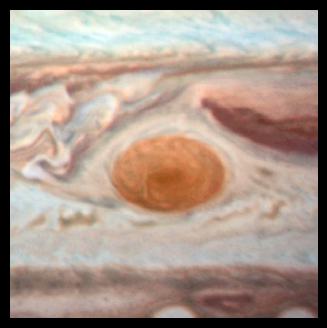

[CAPTION] Using Hubble, astronomers regularly track Jupiter’s 
Great Red Spot, a giant swirling storm slightly larger 
than Earth. They found that the spot is shrinking 
and jiggling. Its outer winds are speeding up while 
moving significantly more slowly toward its center.

----------------------------------------------------------------------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Expected images : True
{'query': 'What observational evidence from Hubble images supports the conclusion that the breakup of asteroid P/2013 R3 was not caused by a collision?', 'text_context': '[1] Asteroid P/2013 R3\nAsteroid P/2013 R3\nHubble watched the slow \ndisintegration of asteroid P/2013 \nR3 into 10 smaller pieces. The \nHubble data revealed that the \nfragments are drifting away from \nea

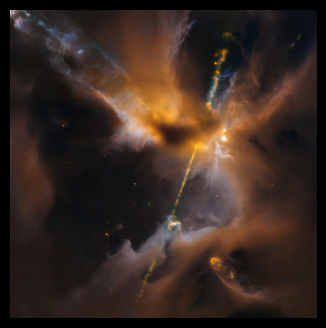

[CAPTION] Hubble’s observations 
of nebulae reveal bizarre 
landscapes sculpted by 
radiation from young, 
exceptionally bright stars. 
The observations reveal 
the violent process of star 
birth that produces intense 
ultraviolet radiation and shock 
fronts. The radiation clears 
out cavities in stellar nursery 
clouds and erodes material 
from giant gas pillars that are 
incubators for fledgling stars. Jets Blasts from Young Stars HERBIG-HARO JET HH 24

----------------------------------------------------------------------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Expected images : True
{'query': 'Why were light echo images, such as those of V838 Monocerotis, crucial for distinguishing between physical expansion of matter and the propagation of light through surrounding dust?', 

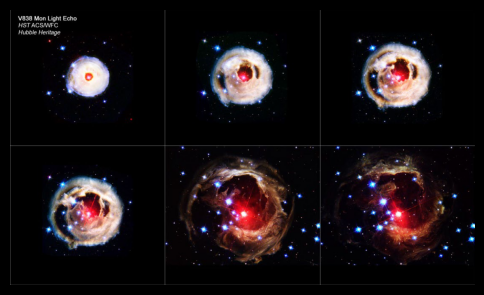

[CAPTION] Expanding Light Echo of V838 Monocerotis

----------------------------------------------------------------------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Expected images : False
{'query': 'Explain how Hubble observations of Cepheid variable stars and Type Ia supernovae together strengthened the cosmic distance ladder.', 'text_context': '[1] Hubble observations, along \nwith those of ground-based \nobservatories, surprised \nastronomers by revealing \nthat the universe is not just \nexpanding but accelerating \n– a discovery that won the \n2011 Nobel Prize in Physics. \nAstronomers use stars like \nCepheid variables and Type \nIa supernovae to determine \nastronomical distances \nbecause these types of \nstars have well-known \nbrightness curves.\n(Source: hubble-science

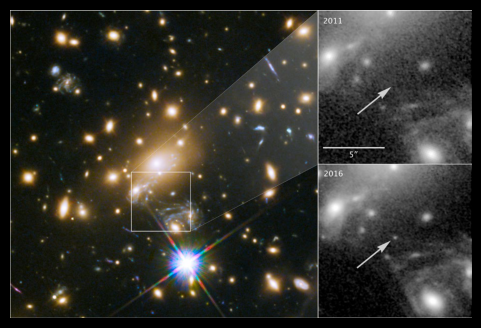

[CAPTION] FOCUSING IN ON GRAVITATIONAL LENSES

----------------------------------------------------------------------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Expected images : False
{'query': 'How did Hubble’s observations of galaxy mergers change earlier assumptions that galaxies evolve in isolation?', 'text_context': '[1] Galaxy Details and Mergers\nAstronomer Edwin Hubble pioneered the study of galaxies based \nsimply on their appearance and categorized them according \nto three basic shapes: spiral, elliptical, and irregular. Some 60 \nyears later, the sharp vision of the space telescope named in his \nhonor began seeing unprecedented details in galaxies, revealing \nintricate, dark dust lanes and glowing knots of star formation. \nHubble observations showed galaxies often i

In [21]:
# Used to display output from context formatter .
for output in retrieval_output:
    print("-" * 160)

    context = formatter.format(output.get("result"))

    print(f"Expected images : {output.get('expected_images')}")
    print(context)

    images = context.get("images", [])

    if images:
        print(f"[INFO] {len(images)} image(s) found\n")

        for idx, img_data in enumerate(images):
            img = img_data.get("image")
            caption = img_data.get("caption", "No caption")

            if isinstance(img, Image.Image):
                plt.figure(figsize=(6, 4))
                plt.imshow(img)
                plt.axis("off")
                # plt.title(f"Image {idx + 1}")
                plt.show()

                print(f"[CAPTION] {caption}\n")
            else:
                print(f"[WARNING] Image {idx + 1} is not a PIL image")
    else:
        print("[INFO] No images in formatted context")

    print("-" * 160)